In [1]:
import pickle

with open("insight_student_embeddings_test.pkl", "rb") as f:
    embeddings = pickle.load(f)

embeddings["filenames"] = sum(embeddings["filenames"], [])
filenames = embeddings["filenames"] 

id_to_embedding = {}
for i in range(len(embeddings["filenames"])):
    id = embeddings["filenames"][i].replace("/path/to/ms1m-arcface/", "").split("/")[0]
    exsting = id_to_embedding.get(id, [])
    exsting.append({
        "teacher": embeddings["teacher_embeddings"][i],
        "student": embeddings["student_embeddings"][i],
    })

    id_to_embedding[id] = exsting 

import torch
embeddings = {"teacher": [], "student": []}
embeddings_another = {"teacher": [], "student": []}
for key in id_to_embedding:
    items = id_to_embedding[key]
    if len(items) < 2:
        continue
    embeddings["teacher"].append(items[0]["teacher"])
    embeddings["student"].append(items[0]["student"]) 
    embeddings_another["teacher"].append(items[1]["teacher"])
    embeddings_another["student"].append(items[1]["student"])

embeddings["teacher"] = torch.stack(embeddings["teacher"], dim=0)
embeddings["student"] = torch.stack(embeddings["student"], dim=0)
embeddings_another["teacher"] = torch.stack(embeddings_another["teacher"], dim=0)
embeddings_another["student"] = torch.stack(embeddings_another["student"], dim=0)

In [2]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [3]:
student_embeddings = embeddings["student"]
teacher_embeddings = embeddings["teacher"] 

In [4]:
embeddings.keys()

dict_keys(['teacher', 'student'])

In [5]:
from ip_adapter.ip_adapter_faceid import IPAdapterFaceIDXL
import torch
from diffusers import StableDiffusionXLPipeline, DDIMScheduler
from PIL import Image

base_model_path = "stablediffusionapi/realism-engine-sdxl"
# base_model_path = "SG161222/RealVisXL_V3.0"
ip_ckpt = "ip-adapter-faceid_sdxl.bin"
device = "cuda"

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)
pipe = StableDiffusionXLPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    add_watermarker=False,
)

# load ip-adapter
ip_model = IPAdapterFaceIDXL(pipe, ip_ckpt, device)

RuntimeError: Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
expected string or bytes-like object

In [6]:
torch.nn.functional.cosine_similarity(student_embeddings, teacher_embeddings[:,0], dim=1).argsort()

tensor([0])

In [55]:
idx = 0
print(torch.nn.functional.cosine_similarity(student_embeddings, teacher_embeddings[:,0], dim=1)[idx])
# faceid = teacher_embeddings[idx:idx+1] / teacher_embeddings[idx:idx+1].norm()
# faceid = faceid[:,0]
faceid = student_embeddings[idx:idx+1] / student_embeddings[idx:idx+1].norm()

tensor(0.6883)


In [56]:
faceid.shape

torch.Size([1, 512])

In [79]:
import cv2
import random
# generate image
prompt = "a cute college man running on train station platform, photorealistic, high quality, 8k" 
negative_prompt = "ugly, beard"

 
images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid, num_samples=1, width=1024, height=1024, num_inference_steps=50, seed=random.randint(0, 1000000), scale=1.0, guidance_scale=3.5
)

  0%|          | 0/50 [00:00<?, ?it/s]

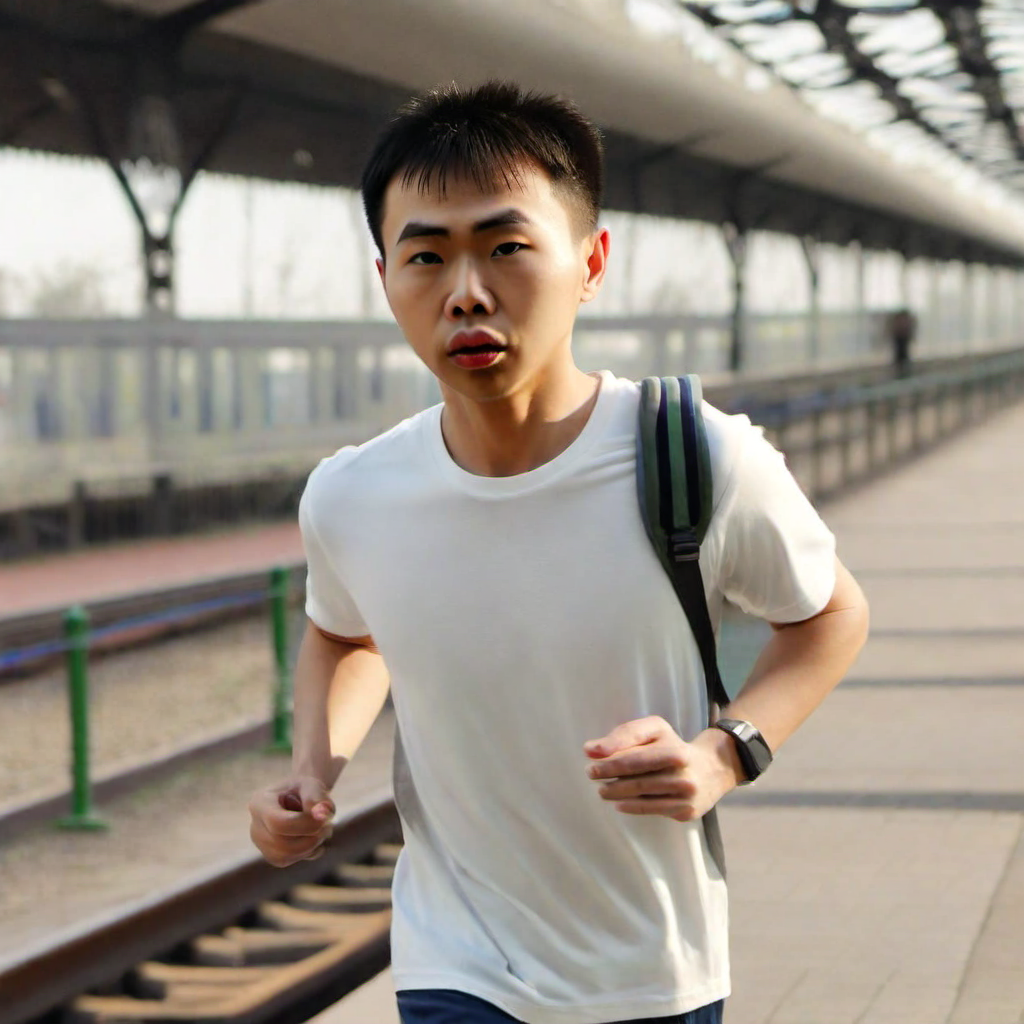

In [80]:
images[0]   

In [16]:
Image.open("val/"+filenames[idx])

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/FaceLinkGen/val/wenqi2.png'

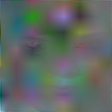

In [20]:
Image.fromarray((student_images[idx].permute(1,2,0).numpy()*128 + 128).astype('uint8'))


In [118]:
cv2_image = (student_images[idx].permute(1,2,0).numpy()*128 + 128).astype('uint8')

In [150]:
def highpass(img, sigma):
    img = np.abs(img - cv2.GaussianBlur(img, (0, 0), sigma)).max(-1) + 127
    img = np.clip(img, 0, 255).astype('uint8')
    img = (img - img.min()) / (img.max() - img.min()) * 255
    return img

(np.float64(-0.5), np.float64(111.5), np.float64(111.5), np.float64(-0.5))

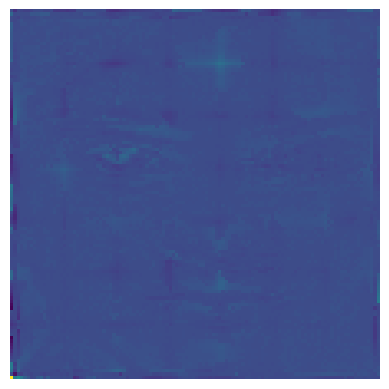

In [151]:
import pylab 
pylab.imshow(highpass(cv2_image, 2))
pylab.axis("off")

In [20]:
import os
os.makedirs("generated_images", exist_ok=True)
for i, img in enumerate(images):
    img.save(f"generated_images/generated_image_{i}.png")

In [21]:
from PIL import ImageDraw, ImageFont
import PIL

original_face = Image.open("val/"+filenames[idx]).resize((512, 512))
protected_face = Image.fromarray((student_images[idx].permute(1,2,0).numpy()*128 + 128).astype('uint8')).resize((512, 512))
generated_image = images[0].resize((1024, 1024))

# font_path = PIL.__path__[0] + "/fonts/DejaVuSans.ttf"
# font = ImageFont.truetype(font_path, size=60)

# def add_label(img, text):
#     img = img.copy()
#     d = ImageDraw.Draw(img)
#     d.text((10, 10), text, fill=(255, 255, 255), font=font)
#     return img

# original_face = add_label(original_face, "(a)")
# protected_face = add_label(protected_face, "(b)")
# generated_image = add_label(generated_image, "(c)")

# left_col = vstack([original_face, protected_face])
# hstack([left_col, generated_image])


In [22]:
from insightface.app import FaceAnalysis
app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(640, 640))

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

In [23]:
def crop_face(img): 
    image = np.array(img)
    faces = app.get(image)
    bbox = faces[0].bbox.astype(int)
    x1, y1, x2, y2 = bbox
    face_img = image[y1:y2, x1:x2]
    return Image.fromarray(face_img).resize((512, 512))

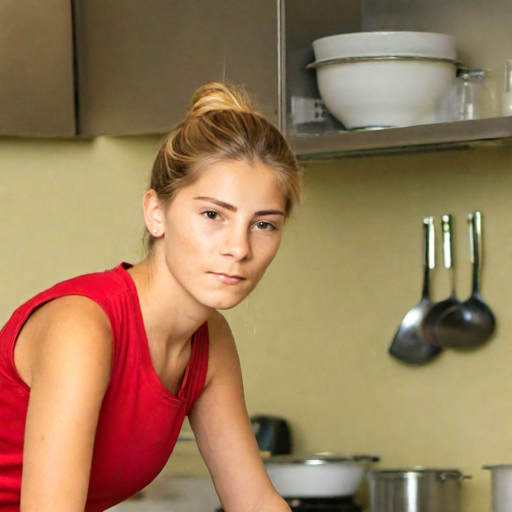

In [24]:
generated_image.resize((512, 512))

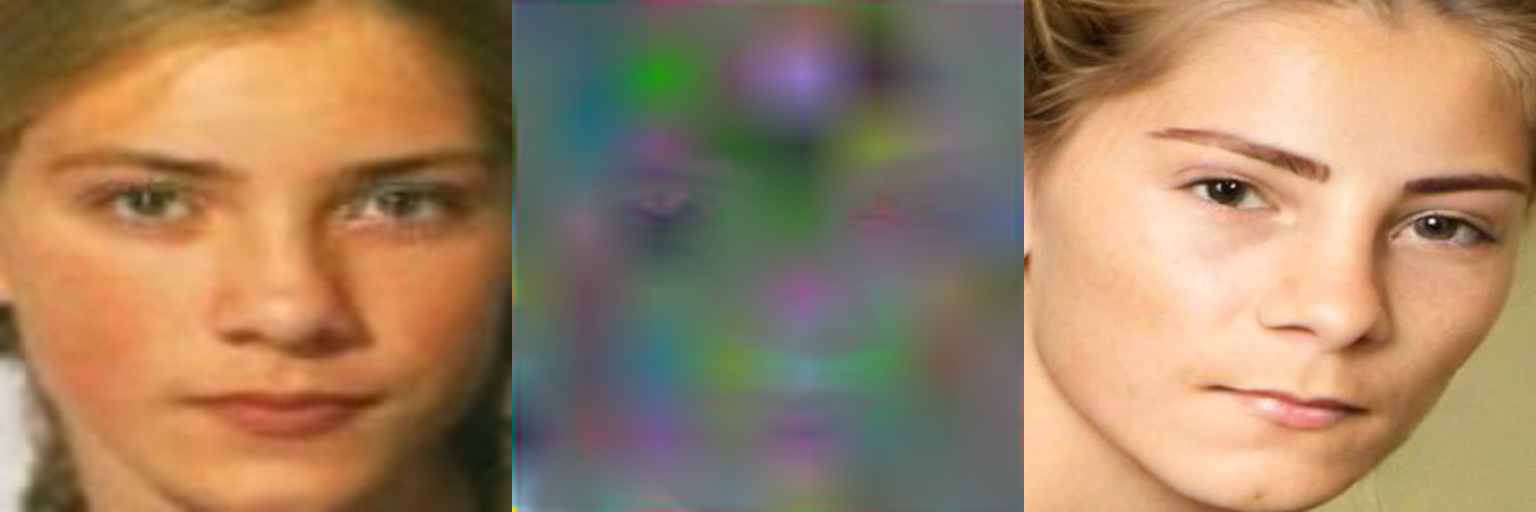

In [25]:
hstack([original_face, protected_face, crop_face(generated_image)])

In [26]:
import requests
from io import BytesIO

def compare_faces(img1, img2, api_key, api_secret):
    buf1 = BytesIO()
    img1.save(buf1, format="JPEG")
    buf1.seek(0)

    buf2 = BytesIO()
    img2.save(buf2, format="JPEG")
    buf2.seek(0)

    files = {
        "image_file1": ("img1.jpg", buf1, "image/jpeg"),
        "image_file2": ("img2.jpg", buf2, "image/jpeg")
    }

    data = {
        "api_key": api_key,
        "api_secret": api_secret
    }

    r = requests.post(
        "https://api-us.faceplusplus.com/facepp/v3/compare",
        data=data,
        files=files
    )
    return r.json()

In [29]:
compare_faces(original_face, Image.fromarray(np.zeros((512, 512, 3), dtype=np.uint8)), "5W5RrSIa4Vk_AC7uLfXGjL2Vu8WGf9Qo", "X19PnBAW-reeXBt5I57uCxuH5uoQFMEi")

{'request_id': '1765430290,eb4ece31-53be-42ae-bec6-3ba52ee70f0b',
 'time_used': 46,
 'faces1': [{'face_token': 'd152a87442f1c927fa2479383c6f57aa',
   'face_rectangle': {'top': 81, 'left': 8, 'width': 515, 'height': 515}}],
 'faces2': [],
 'image_id1': '1kcLybmZYVOyVnTzhrztVA==',
 'image_id2': 'JlzxE3HGpck53qMC4eLzMQ=='}